# Rotated Rectangle Bounding Box for Semantic Blobs

This notebook demonstrates the end-to-end workflow for detecting non-overlapping connected components (blobs) in a binary semantic segmentation mask, computing strictly enclosing rotated rectangles that maximize the Intersection-over-Union (IoU) metric, visualizing the results, and exporting bounding box coordinates to CSV.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Polygon

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    import matplotlib

    matplotlib.use("Agg")

from blob_bounding_box import (
    calculate_rotated_bounding_box,
    configure_logging,
    extract_blobs,
    load_binary_mask,
    process_mask_pipeline,
)

# Enable informative trace logging
configure_logging(level="INFO")

## 1. Load and Inspect Binary Semantic Mask

We load the sample mask from `data/example_mask.png`.

In [2]:
mask_path = Path("../data/example_mask.png")
if not mask_path.exists():
    mask_path = Path("data/example_mask.png")

mask = load_binary_mask(mask_path)
print(f"Loaded mask dimensions: {mask.width} x {mask.height}")
print(f"Total foreground pixels: {(mask.data > 0).sum():,}")

2026-10-01 20:34:42.459 | INFO     | blob_bounding_box.mask_loader:load_binary_mask:43 - Loaded mask example_mask.png: 2048x2048, foreground pixels: 16700


Loaded mask dimensions: 2048 x 2048
Total foreground pixels: 16,700


## 2. Extract Blobs and Calculate Rotated Bounding Boxes

In [3]:
# Extract connected components (8-connectivity)
blobs = extract_blobs(mask, min_area_threshold=1)
print(f"Total blobs identified: {len(blobs)}")

# Calculate minimum-area rotated bounding boxes maximizing IoU
boxes = [calculate_rotated_bounding_box(b) for b in blobs]
mean_iou = float(np.mean([box.iou for box in boxes]))
print(f"Mean IoU across all blobs: {mean_iou:.4f}")

2026-10-01 20:34:42.473 | INFO     | blob_bounding_box.detector:extract_blobs:23 - Extracting blobs with connectivity=8, min_area_threshold=1
2026-10-01 20:34:42.490 | INFO     | blob_bounding_box.detector:extract_blobs:76 - Blob extraction complete: 147 retained, 0 filtered (< 1 px)


Total blobs identified: 147
Mean IoU across all blobs: 0.9657


## 3. Visualize Mask and Rotated Bounding Boxes Overlay

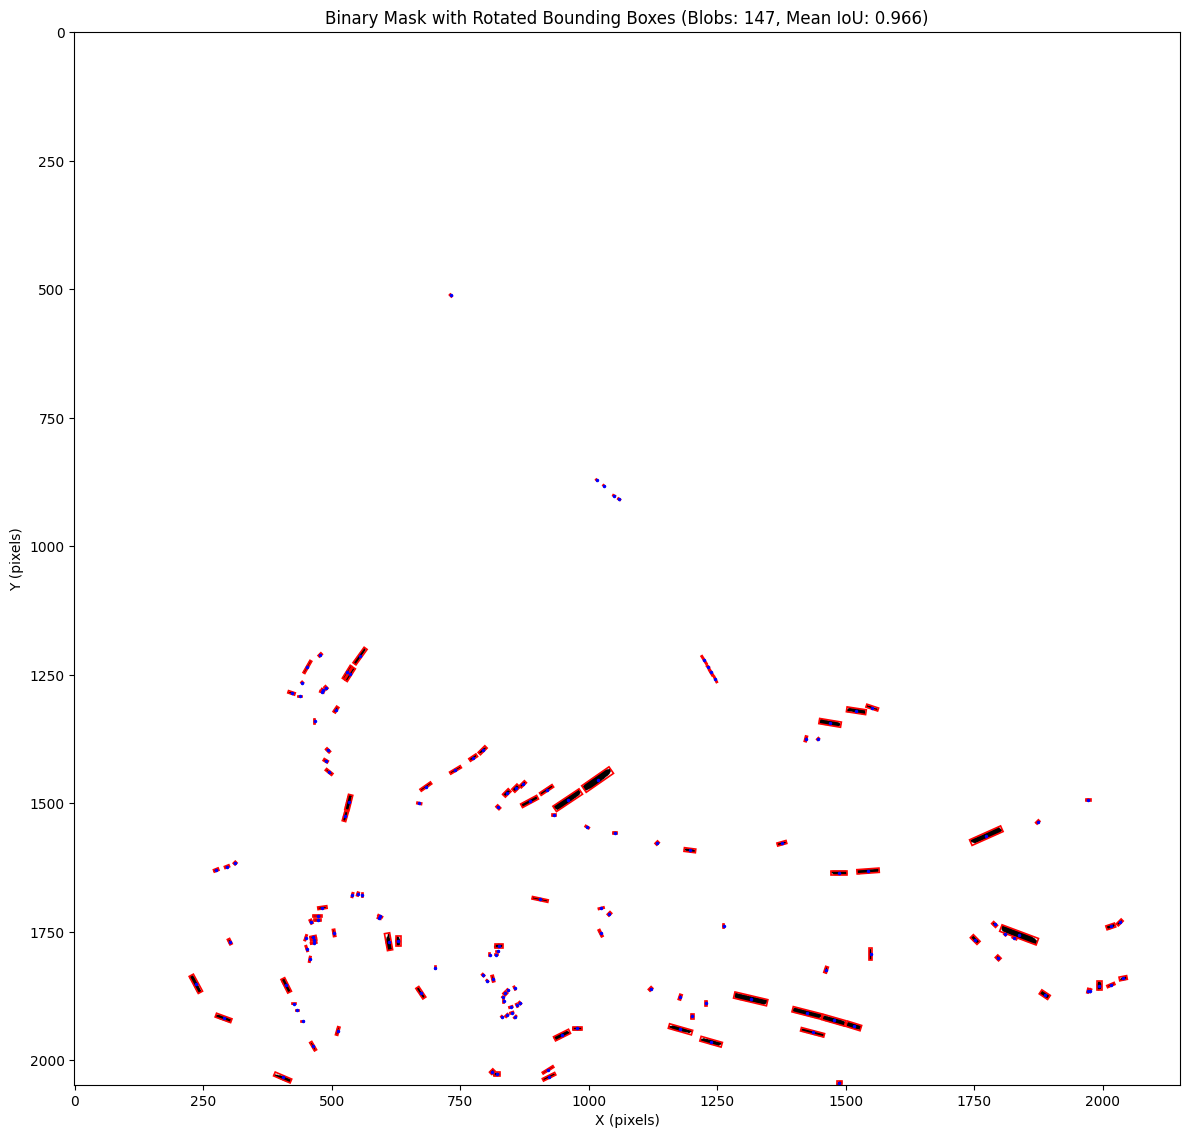

In [4]:
fig, ax = plt.subplots(figsize=(12, 12))
ax.imshow(mask.data, cmap="gray_r")

# Overlay each bounding box as a polygon using clockwise corner vertices
for box in boxes:
    poly = Polygon(box.corners, fill=False, edgecolor="red", linewidth=1.2)
    ax.add_patch(poly)
    ax.plot(box.center_x, box.center_y, "b.", markersize=3)

title = f"Binary Mask with Rotated Bounding Boxes (Blobs: {len(boxes)}, Mean IoU: {mean_iou:.3f})"
ax.set_title(title)
ax.set_xlabel("X (pixels)")
ax.set_ylabel("Y (pixels)")
plt.tight_layout()
plt.show()

## 4. Zoomed-in Inspection of Individual Blobs

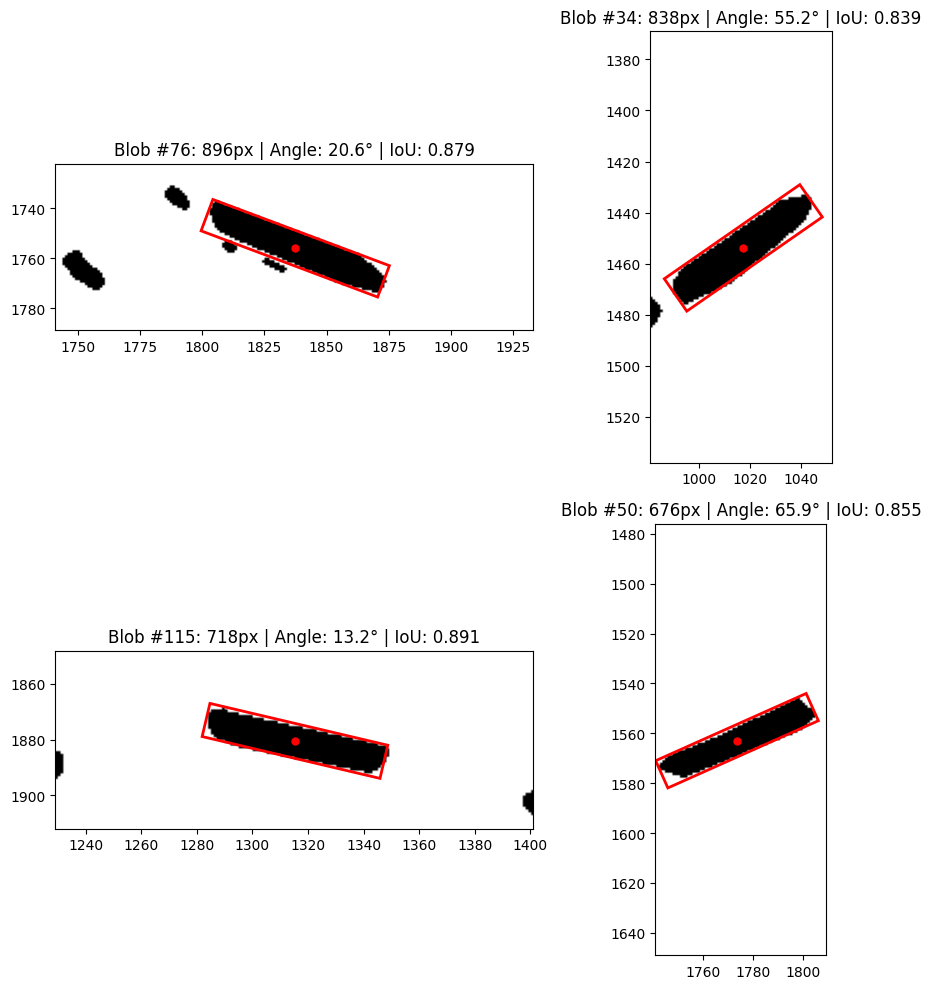

In [5]:
# Select top 4 largest blobs to inspect tight bounding alignment
sorted_blobs = sorted(blobs, key=lambda b: b.pixel_count, reverse=True)[:4]

fig, axes = plt.subplots(2, 2, figsize=(10, 10))
for idx, blob in enumerate(sorted_blobs):
    r, c = divmod(idx, 2)
    ax = axes[r, c]
    box = calculate_rotated_bounding_box(blob)

    # Compute bounding viewport around blob
    margin = 20
    min_x = max(int(box.center_x - box.width - margin), 0)
    max_x = min(int(box.center_x + box.width + margin), mask.width)
    min_y = max(int(box.center_y - box.height - margin), 0)
    max_y = min(int(box.center_y + box.height + margin), mask.height)

    sub_data = mask.data[min_y:max_y, min_x:max_x]
    ax.imshow(sub_data, cmap="gray_r", extent=[min_x, max_x, max_y, min_y])
    poly = Polygon(box.corners, fill=False, edgecolor="red", linewidth=2.0)
    ax.add_patch(poly)
    ax.plot(box.center_x, box.center_y, "ro", markersize=5)
    lbl = (
        f"Blob #{box.blob_id}: {blob.pixel_count}px | Angle: {box.angle:.1f}° | IoU: {box.iou:.3f}"
    )
    ax.set_title(lbl)

plt.tight_layout()
plt.show()

## 5. End-to-End Pipeline & CSV Export

In [6]:
csv_path, summary = process_mask_pipeline(mask_path, output_dir=".")
print(f"CSV exported to: {csv_path}")
print(f"Total records exported: {summary.exported_records_count}")
print(f"Mean IoU: {summary.mean_iou:.4f}")
print(f"Elapsed time: {summary.elapsed_seconds:.4f} s")

2026-10-01 20:34:43.994 | INFO     | blob_bounding_box.pipeline:process_mask_pipeline:52 - Starting blob bounding box pipeline for /home/tushar/blob-bounding-box-generation/data/example_mask.png
2026-10-01 20:34:44.010 | INFO     | blob_bounding_box.mask_loader:load_binary_mask:43 - Loaded mask example_mask.png: 2048x2048, foreground pixels: 16700
2026-10-01 20:34:44.015 | INFO     | blob_bounding_box.detector:extract_blobs:23 - Extracting blobs with connectivity=8, min_area_threshold=1
2026-10-01 20:34:44.024 | INFO     | blob_bounding_box.detector:extract_blobs:76 - Blob extraction complete: 147 retained, 0 filtered (< 1 px)
2026-10-01 20:34:44.025 | INFO     | blob_bounding_box.pipeline:process_mask_pipeline:64 - Computing rotated bounding boxes for 147 blobs
2026-10-01 20:34:44.035 | INFO     | blob_bounding_box.exporter:export_bounding_boxes_to_csv:37 - Exporting 147 bounding box records to /home/tushar/blob-bounding-box-generation/notebooks/blob_bounding_boxes_20261001_203444.csv

CSV exported to: /home/tushar/blob-bounding-box-generation/notebooks/blob_bounding_boxes_20261001_203444.csv
Total records exported: 147
Mean IoU: 0.9657
Elapsed time: 0.0443 s


## 6. Preview Exported CSV Records

In [7]:
with open(csv_path, "r", encoding="utf-8") as f:
    lines = [f.readline().strip() for _ in range(11)]

print("\n".join(lines))

blob_id,center_x,center_y,width,height,angle
1,732.0,512.0,5.66,2.83,45.0
2,1015.5,871.0,3.54,2.12,45.0
3,1029.75,882.25,4.24,2.12,45.0
4,1049.5,901.5,4.92,2.24,26.57
5,1059.27,908.35,5.27,2.5,33.69
6,555.25,1213.54,7.21,37.07,35.75
7,477.75,1211.25,4.24,7.78,45.0
8,1224.55,1220.97,18.34,2.44,57.99
9,452.85,1234.63,4.09,27.29,29.74
10,1232.0,1234.0,5.66,2.83,45.0


## 7. Noise Filtering Analysis & Summary Reporting

Compare standard extraction against noise-filtered extraction.

In [8]:
thresholds = [1, 20, 50, 100]
print(f"{'Threshold (px)':<15} {'Retained Blobs':<15} {'Filtered Blobs':<15} {'Mean IoU':<12}")
print("-" * 57)

for thresh in thresholds:
    _, s = process_mask_pipeline(mask_path, output_dir=".", min_area_threshold=thresh)
    print(
        f"{thresh:<15} {s.exported_records_count:<15} "
        f"{s.filtered_components_count:<15} {s.mean_iou:<12.4f}"
    )

2026-10-01 20:34:44.157 | INFO     | blob_bounding_box.pipeline:process_mask_pipeline:52 - Starting blob bounding box pipeline for /home/tushar/blob-bounding-box-generation/data/example_mask.png
2026-10-01 20:34:44.177 | INFO     | blob_bounding_box.mask_loader:load_binary_mask:43 - Loaded mask example_mask.png: 2048x2048, foreground pixels: 16700
2026-10-01 20:34:44.184 | INFO     | blob_bounding_box.detector:extract_blobs:23 - Extracting blobs with connectivity=8, min_area_threshold=1
2026-10-01 20:34:44.194 | INFO     | blob_bounding_box.detector:extract_blobs:76 - Blob extraction complete: 147 retained, 0 filtered (< 1 px)
2026-10-01 20:34:44.195 | INFO     | blob_bounding_box.pipeline:process_mask_pipeline:64 - Computing rotated bounding boxes for 147 blobs
2026-10-01 20:34:44.203 | INFO     | blob_bounding_box.exporter:export_bounding_boxes_to_csv:37 - Exporting 147 bounding box records to /home/tushar/blob-bounding-box-generation/notebooks/blob_bounding_boxes_20261001_203444.csv

Threshold (px)  Retained Blobs  Filtered Blobs  Mean IoU    
---------------------------------------------------------
1               147             0               0.9657      


2026-10-01 20:34:44.246 | INFO     | blob_bounding_box.exporter:export_bounding_boxes_to_csv:37 - Exporting 128 bounding box records to /home/tushar/blob-bounding-box-generation/notebooks/blob_bounding_boxes_20261001_203444.csv
2026-10-01 20:34:44.248 | INFO     | blob_bounding_box.exporter:export_bounding_boxes_to_csv:45 - Successfully wrote blob_bounding_boxes_20261001_203444.csv to /home/tushar/blob-bounding-box-generation/notebooks/blob_bounding_boxes_20261001_203444.csv
2026-10-01 20:34:44.249 | INFO     | blob_bounding_box.pipeline:process_mask_pipeline:103 - Pipeline completed in 0.041s: 128 blobs exported to blob_bounding_boxes_20261001_203444.csv, mean IoU: 0.961
2026-10-01 20:34:44.250 | INFO     | blob_bounding_box.pipeline:process_mask_pipeline:52 - Starting blob bounding box pipeline for /home/tushar/blob-bounding-box-generation/data/example_mask.png
2026-10-01 20:34:44.267 | INFO     | blob_bounding_box.mask_loader:load_binary_mask:43 - Loaded mask example_mask.png: 2048x

20              128             19              0.9606      
50              72              75              0.9339      


2026-10-01 20:34:44.312 | INFO     | blob_bounding_box.detector:extract_blobs:76 - Blob extraction complete: 48 retained, 99 filtered (< 100 px)
2026-10-01 20:34:44.313 | INFO     | blob_bounding_box.pipeline:process_mask_pipeline:64 - Computing rotated bounding boxes for 48 blobs
2026-10-01 20:34:44.318 | INFO     | blob_bounding_box.exporter:export_bounding_boxes_to_csv:37 - Exporting 48 bounding box records to /home/tushar/blob-bounding-box-generation/notebooks/blob_bounding_boxes_20261001_203444.csv
2026-10-01 20:34:44.319 | INFO     | blob_bounding_box.exporter:export_bounding_boxes_to_csv:45 - Successfully wrote blob_bounding_boxes_20261001_203444.csv to /home/tushar/blob-bounding-box-generation/notebooks/blob_bounding_boxes_20261001_203444.csv
2026-10-01 20:34:44.320 | INFO     | blob_bounding_box.pipeline:process_mask_pipeline:103 - Pipeline completed in 0.031s: 48 blobs exported to blob_bounding_boxes_20261001_203444.csv, mean IoU: 0.916


100             48              99              0.9161      
